# Two-Stage Stitching with Known Camera Positions

This notebook implements a two-stage stitching approach:
1. **Stage 1**: Homography-based stitching within each ESP group
2. **Stage 2**: Position-based stitching using known ESP locations (front, left, right, back) with optional fine-tuning

The ESP cameras are positioned at approximately 90° intervals:
- ESP2: Front (0°)
- ESP3: Left (90°) 
- ESP1: Right (270°/-90°)
- ESP4: Back (180°)


In [1]:
import os
from pathlib import Path
from typing import List, Tuple, Dict, Optional
import time
import re
import math

import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

from stitching.feature_detector import FeatureDetector
from stitching.feature_matcher import FeatureMatcher
from stitching.camera_estimator import CameraEstimator
from stitching.camera_adjuster import CameraAdjuster
from stitching.camera_wave_corrector import WaveCorrector
from stitching.warper import Warper
from stitching.seam_finder import SeamFinder
from stitching.exposure_error_compensator import ExposureErrorCompensator
from stitching.blender import Blender
from stitching.subsetter import Subsetter

np.set_printoptions(suppress=True, linewidth=140)

def plot_image(img, figsize=(6,6), title=None):
    fig, ax = plt.subplots(figsize=figsize)
    if img.ndim == 2:
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    if title:
        ax.set_title(title)
    ax.axis('off')
    plt.show()

def plot_images(imgs, titles=None, figsize=(16,6)):
    n = len(imgs)
    fig, axs = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axs = [axs]
    for i, img in enumerate(imgs):
        if img.ndim == 2:
            axs[i].imshow(img, cmap='gray')
        else:
            axs[i].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        if titles is not None:
            axs[i].set_title(titles[i])
        axs[i].axis('off')
    plt.tight_layout()
    plt.show()

## Configuration and ESP-based image grouping

In [2]:
# Directory of input images
IMAGE_DIR = "final/data/calibration_run"  # change if needed
EXTS = (".jpg", ".jpeg", ".png", ".bmp")

# Optionally override with explicit list
IMAGE_PATHS: List[str] = []

# ESP Physical Positions (in degrees, 0° = front/north)
ESP_POSITIONS = {
    'esp_2': 0,      # Front
    'esp_3': 90,     # Left  
    'esp_1': 270,    # Right (-90°)
    'esp_4': 180     # Back
}

def list_images_sorted(image_dir: str) -> List[str]:
    files = [str(Path(image_dir) / f) for f in os.listdir(image_dir)
             if f.lower().endswith(EXTS) and not f.startswith('.')]
    files.sort()
    return files

def extract_esp_id(filename: str) -> str:
    """Extract ESP ID from filename like 'esp_1_timestamp.jpg' -> 'esp_1'"""
    basename = Path(filename).stem
    # Look for pattern like esp_X where X is a number
    match = re.match(r'(esp_\d+)', basename.lower())
    if match:
        return match.group(1)
    # Fallback: use first part before underscore if it contains 'esp'
    parts = basename.lower().split('_')
    for i, part in enumerate(parts):
        if 'esp' in part and i < len(parts) - 1:
            return f"{part}_{parts[i+1]}"
    # If no ESP pattern found, group by first part of filename
    return parts[0] if parts else "unknown"

def group_images_by_esp(image_paths: List[str]) -> Dict[str, List[str]]:
    """Group image paths by ESP device ID"""
    groups = {}
    for path in image_paths:
        esp_id = extract_esp_id(Path(path).name)
        if esp_id not in groups:
            groups[esp_id] = []
        groups[esp_id].append(path)
    return groups

if IMAGE_PATHS:
    imgs_list = [str(Path(p)) for p in IMAGE_PATHS]
else:
    imgs_list = list_images_sorted(IMAGE_DIR)

print(f"Found {len(imgs_list)} images")

# Group by ESP
esp_groups = group_images_by_esp(imgs_list)
print(f"\nGrouped into {len(esp_groups)} ESP devices:")
for esp_id, paths in esp_groups.items():
    position = ESP_POSITIONS.get(esp_id, "unknown")
    direction = {0: "Front", 90: "Left", 180: "Back", 270: "Right"}.get(position, f"{position}°")
    print(f"  {esp_id} ({direction}): {len(paths)} images")
    for i, path in enumerate(paths[:3]):  # Show first 3
        print(f"    • {Path(path).name}")
    if len(paths) > 3:
        print(f"    ... and {len(paths)-3} more")

assert len(esp_groups) >= 2, "Need at least two ESP groups to create final panorama"

Found 42 images

Grouped into 4 ESP devices:
  esp_1 (Right): 12 images
    • esp_1_1757157562687.jpg
    • esp_1_1757157562915.jpg
    • esp_1_1757157563438.jpg
    ... and 9 more
  esp_2 (Front): 12 images
    • esp_2_1757157562695.jpg
    • esp_2_1757157562819.jpg
    • esp_2_1757157563430.jpg
    ... and 9 more
  esp_3 (Left): 7 images
    • esp_3_1757157562669.jpg
    • esp_3_1757157562983.jpg
    • esp_3_1757157563605.jpg
    ... and 4 more
  esp_4 (Back): 11 images
    • esp_4_1757157562586.jpg
    • esp_4_1757157563076.jpg
    • esp_4_1757157563116.jpg
    ... and 8 more


## Stitching parameters

In [3]:
WORK_MPIX = 0.6  # Resolution for intra-ESP stitching
HIGH_MPIX = 1.2  # Higher resolution for final inter-ESP stitching
DETECTOR = "orb"   # orb | brisk | akaze | sift
N_FEATURES_INTRA = 3000  # Features for intra-ESP (high overlap)
N_FEATURES_INTER = 8000  # More features for inter-ESP (lower overlap)

def resize_to_megapix(img: np.ndarray, target_mpix: float, allow_upscale: bool = False) -> np.ndarray:
    if target_mpix is None or target_mpix <= 0:
        return img
    h, w = img.shape[:2]
    cur_mpix = (w * h) / 1e6
    if cur_mpix <= 0:
        return img
    scale = np.sqrt(target_mpix / cur_mpix)
    if scale >= 1.0 and not allow_upscale:
        return img
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    interp = cv.INTER_AREA if scale < 1.0 else cv.INTER_LINEAR
    return cv.resize(img, (new_w, new_h), interpolation=interp)

## Stage 1: Homography-based stitching within each ESP group


STAGE 1 (Homography): Stitching ESP group 'esp_1' (12 images)
Image sizes: ['800x600', '800x600', '800x600']
  - Stitching frame 1/11 into panorama...
  - Stitching frame 2/11 into panorama...
  - Stitching frame 3/11 into panorama...
  - Stitching frame 4/11 into panorama...
  - Stitching frame 5/11 into panorama...
  - Stitching frame 6/11 into panorama...
  - Stitching frame 7/11 into panorama...
  - Stitching frame 8/11 into panorama...
  - Stitching frame 9/11 into panorama...
  - Stitching frame 10/11 into panorama...
  - Stitching frame 11/11 into panorama...
ESP 'esp_1' homography stitching completed: 3662x2523
Saved: esp_esp_1_homography.jpg


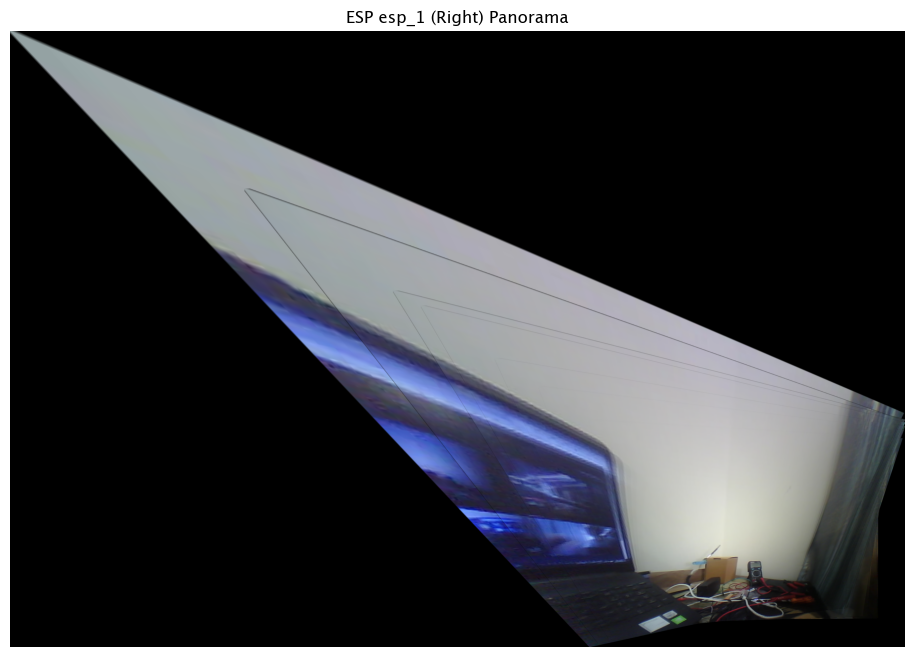


STAGE 1 (Homography): Stitching ESP group 'esp_2' (12 images)
Image sizes: ['800x600', '800x600', '800x600']
  - Stitching frame 1/11 into panorama...
  - Stitching frame 2/11 into panorama...
  - Stitching frame 3/11 into panorama...
  - Stitching frame 4/11 into panorama...
  - Stitching frame 5/11 into panorama...
  - Stitching frame 6/11 into panorama...
  - Stitching frame 7/11 into panorama...
  - Stitching frame 8/11 into panorama...
  - Stitching frame 9/11 into panorama...
  - Stitching frame 10/11 into panorama...
  - Stitching frame 11/11 into panorama...
ESP 'esp_2' homography stitching completed: 4971x3799
Saved: esp_esp_2_homography.jpg


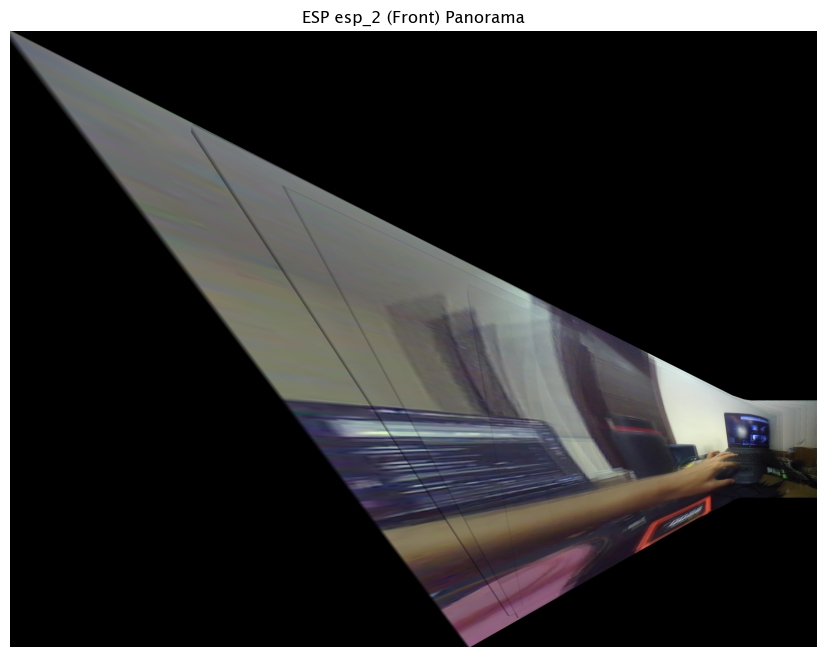


STAGE 1 (Homography): Stitching ESP group 'esp_3' (7 images)
Image sizes: ['800x600', '800x600', '800x600']
  - Stitching frame 1/6 into panorama...
  - Stitching frame 2/6 into panorama...
  - Stitching frame 3/6 into panorama...
  - Stitching frame 4/6 into panorama...
  - Stitching frame 5/6 into panorama...
  - Stitching frame 6/6 into panorama...
ESP 'esp_3' homography stitching completed: 1588x1326
Saved: esp_esp_3_homography.jpg


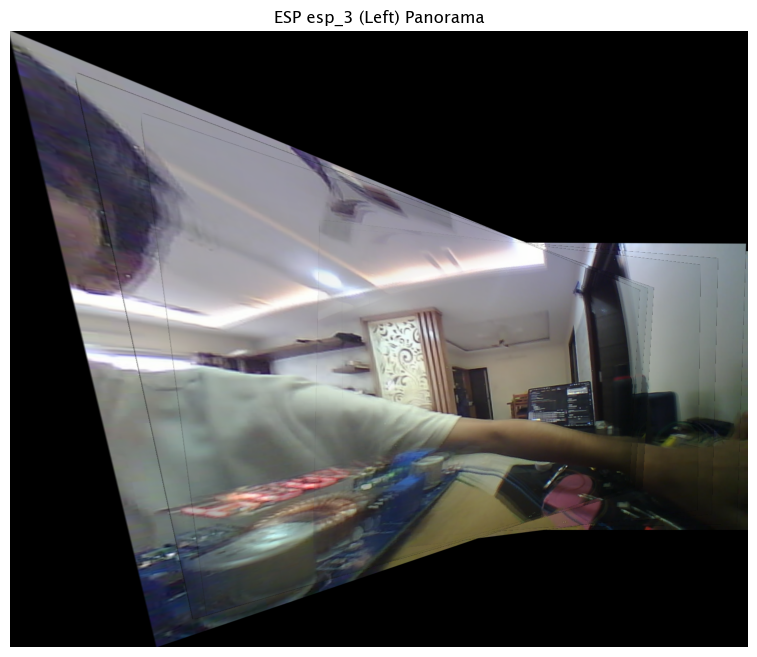


STAGE 1 (Homography): Stitching ESP group 'esp_4' (11 images)
Image sizes: ['640x480', '640x480', '640x480']
  - Stitching frame 1/10 into panorama...
  - Stitching frame 2/10 into panorama...
  - Stitching frame 3/10 into panorama...
  - Stitching frame 4/10 into panorama...
  - Stitching frame 5/10 into panorama...
  - Stitching frame 6/10 into panorama...
  - Stitching frame 7/10 into panorama...
  - Stitching frame 8/10 into panorama...
  - Stitching frame 9/10 into panorama...
  - Stitching frame 10/10 into panorama...
ESP 'esp_4' homography stitching completed: 675x486
Saved: esp_esp_4_homography.jpg


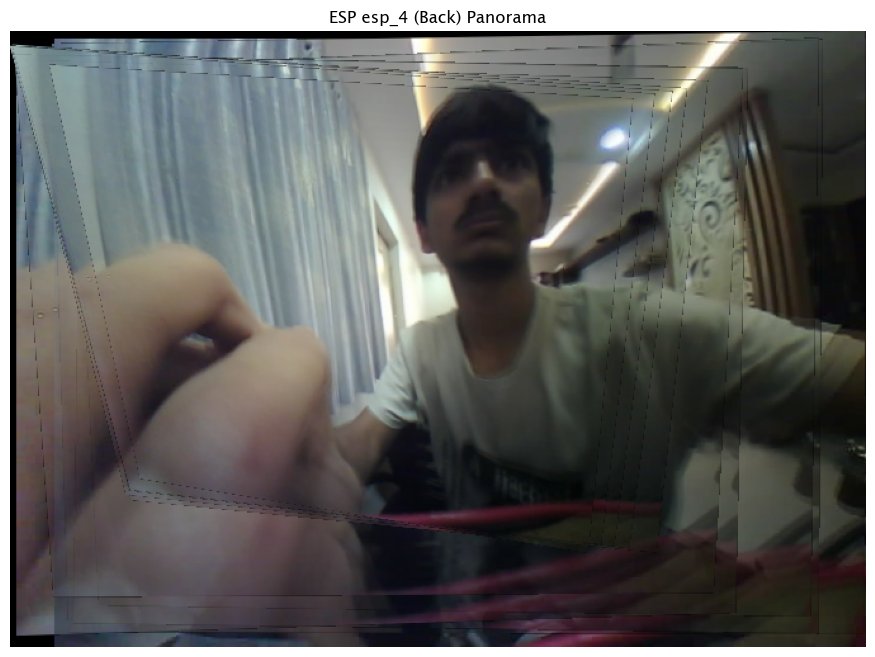


Stage 1 completed: 4 ESP panoramas created

EXPERIMENT: Standard spherical stitch of one frame per ESP (OpenCV Stitcher)
Selected frames (in order): ['esp_2_1757157562695.jpg', 'esp_3_1757157562669.jpg', 'esp_4_1757157562586.jpg', 'esp_1_1757157562687.jpg']
4-ESP spherical stitch failed with status: 1


In [4]:
def stitch_esp_group_homography(image_paths: List[str], esp_id: str, work_mpix: float = 0.6) -> np.ndarray:
    """Stitch images from a single ESP using standard homography panorama (planar)."""
    print(f"\n{'='*60}")
    print(f"STAGE 1 (Homography): Stitching ESP group '{esp_id}' ({len(image_paths)} images)")
    print(f"{'='*60}")
    
    if len(image_paths) == 0:
        return np.zeros((480, 640, 3), dtype=np.uint8)
    if len(image_paths) == 1:
        img = cv.imread(image_paths[0], cv.IMREAD_COLOR)
        return resize_to_megapix(img, work_mpix, allow_upscale=False)
    
    # Load and resize frames
    imgs = []
    for path in image_paths:
        img = cv.imread(path, cv.IMREAD_COLOR)
        if img is None:
            raise ValueError(f"Failed to read image: {path}")
        imgs.append(resize_to_megapix(img, work_mpix, allow_upscale=False))
    
    print(f"Image sizes: {[f'{img.shape[1]}x{img.shape[0]}' for img in imgs[:3]]}")
    
    try:
        # Sequentially stitch frames using homography
        result = imgs[0]
        for i in range(1, len(imgs)):
            print(f"  - Stitching frame {i}/{len(imgs)-1} into panorama...")
            result = simple_stitch_pair(result, imgs[i], detector_type=DETECTOR, n_features=N_FEATURES_INTRA)
        
        # Save intermediate result
        out_path = f"esp_{esp_id}_homography.jpg"
        cv.imwrite(out_path, result)
        print(f"ESP '{esp_id}' homography stitching completed: {result.shape[1]}x{result.shape[0]}")
        print(f"Saved: {out_path}")
        return result
    
    except Exception as e:
        print(f"Homography stitching failed for ESP '{esp_id}': {e}")
        print("Falling back to simple concatenation...")
        try:
            return np.hstack(imgs)
        except Exception:
            return imgs[0] if imgs else np.zeros((480, 640, 3), dtype=np.uint8)

def simple_stitch_pair(img1, img2, detector_type="orb", n_features=2000):
    """Simple homography-based stitching of two images"""
    # Create detector
    if detector_type.lower() == "orb":
        detector = cv.ORB_create(nfeatures=n_features)
        norm = cv.NORM_HAMMING
    elif detector_type.lower() == "sift":
        detector = cv.SIFT_create(nfeatures=n_features)
        norm = cv.NORM_L2
    else:
        detector = cv.ORB_create(nfeatures=n_features)
        norm = cv.NORM_HAMMING
    
    # Detect and match
    kp1, desc1 = detector.detectAndCompute(img1, None)
    kp2, desc2 = detector.detectAndCompute(img2, None)
    
    if desc1 is None or desc2 is None or len(kp1) < 4 or len(kp2) < 4:
        # No features, just concatenate
        return np.hstack([img1, img2])
    
    # Handle UMat objects
    if hasattr(desc1, 'get'):
        desc1 = desc1.get()
    if hasattr(desc2, 'get'):
        desc2 = desc2.get()
    
    # Ensure descriptors are numpy arrays
    if not isinstance(desc1, np.ndarray):
        desc1 = np.array(desc1)
    if not isinstance(desc2, np.ndarray):
        desc2 = np.array(desc2)
    
    if desc1.shape[0] == 0 or desc2.shape[0] == 0:
        return np.hstack([img1, img2])
    
    bf = cv.BFMatcher(norm, crossCheck=False)
    matches = bf.knnMatch(desc1, desc2, k=2)
    
    # Ratio test
    good = []
    for m in matches:
        if len(m) == 2 and m[0].distance < 0.75 * m[1].distance:
            good.append(m[0])
    
    if len(good) < 4:
        return np.hstack([img1, img2])
    
    # Homography
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    
    H, mask = cv.findHomography(dst_pts, src_pts, cv.RANSAC, 5.0)
    if H is None:
        return np.hstack([img1, img2])
    
    # Ensure H is float32
    H = H.astype(np.float32)
    
    # Warp and blend
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    corners2 = np.float32([[0, 0], [w2, 0], [w2, h2], [0, h2]]).reshape(-1, 1, 2)
    corners2_transformed = cv.perspectiveTransform(corners2, H).reshape(-1, 2)
    
    corners1 = np.float32([[0, 0], [w1, 0], [w1, h1], [0, h1]])
    
    all_corners = np.vstack([corners1, corners2_transformed])
    [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel())
    [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel())
    
    # Ensure translation values are valid
    translation = [float(-x_min), float(-y_min)]
    H_translate = np.array([[1.0, 0.0, translation[0]], 
                           [0.0, 1.0, translation[1]], 
                           [0.0, 0.0, 1.0]], dtype=np.float32)
    
    result_width = int(x_max - x_min)
    result_height = int(y_max - y_min)
    
    # Ensure dimensions are positive
    if result_width <= 0 or result_height <= 0:
        return np.hstack([img1, img2])
    
    # Limit maximum size to prevent memory issues
    max_dimension = 10000
    if result_width > max_dimension or result_height > max_dimension:
        print(f"Warning: Result too large ({result_width}x{result_height}), concatenating instead")
        return np.hstack([img1, img2])
    
    try:
        img1_warped = cv.warpPerspective(img1, H_translate, (result_width, result_height))
        img2_warped = cv.warpPerspective(img2, H_translate.dot(H), (result_width, result_height))
        
        # Simple blending
        mask1 = (img1_warped.sum(axis=2) > 0)
        mask2 = (img2_warped.sum(axis=2) > 0)
        overlap = mask1 & mask2
        
        result = img1_warped.copy()
        result[mask2 & (~mask1)] = img2_warped[mask2 & (~mask1)]
        if np.any(overlap):
            result[overlap] = ((img1_warped[overlap].astype(np.float32) + 
                               img2_warped[overlap].astype(np.float32)) / 2).astype(np.uint8)
        
        return result
        
    except Exception as e:
        print(f"Warping failed: {e}, falling back to concatenation")
        return np.hstack([img1, img2])

# Stitch each ESP group
esp_panoramas = {}
for esp_id, image_paths in esp_groups.items():
    panorama = stitch_esp_group_homography(image_paths, esp_id, WORK_MPIX)
    esp_panoramas[esp_id] = panorama
    
    # Show result
    position = ESP_POSITIONS.get(esp_id, "unknown")
    direction = {0: "Front", 90: "Left", 180: "Back", 270: "Right"}.get(position, f"{position}°")
    plot_image(panorama, figsize=(12, 8), title=f"ESP {esp_id} ({direction}) Panorama")

print(f"\nStage 1 completed: {len(esp_panoramas)} ESP panoramas created")

# Quick test: standard spherical stitch of one image from each ESP group
print(f"\n{'='*60}")
print("EXPERIMENT: Standard spherical stitch of one frame per ESP (OpenCV Stitcher)")
print(f"{'='*60}")

ordered_esp_ids = sorted([eid for eid in esp_groups.keys() if eid in ESP_POSITIONS], key=lambda k: ESP_POSITIONS[k])
test_imgs = []
picked_files = []
for eid in ordered_esp_ids:
    paths = esp_groups.get(eid, [])
    if not paths:
        continue
    path = paths[0]  # take the first capture from each ESP
    img = cv.imread(path, cv.IMREAD_COLOR)
    if img is None:
        continue
    img = resize_to_megapix(img, WORK_MPIX, allow_upscale=False)
    test_imgs.append(img)
    picked_files.append(Path(path).name)

print(f"Selected frames (in order): {picked_files}")

if len(test_imgs) >= 2:
    try:
        stitcher = cv.Stitcher_create(cv.Stitcher_PANORAMA)
    except AttributeError:
        stitcher = cv.Stitcher_create()
    status, pano4 = stitcher.stitch(test_imgs)
    if status == 0:
        cv.imwrite("four_esp_spherical_panorama.jpg", pano4)
        plot_image(pano4, figsize=(12, 8), title="4-ESP spherical panorama (standard)")
        print("Saved: four_esp_spherical_panorama.jpg")
    else:
        print(f"4-ESP spherical stitch failed with status: {status}")
else:
    print("Not enough ESP groups/images for spherical test.")

## Stage 2: Position-based stitching with optional fine-tuning

Starting Stage 2: Position-based inter-ESP stitching...

STAGE 2: Position-based stitching of 4 ESP panoramas
Creating position-based cameras:
  ESP esp_2 (Front, 0°): focal=250.0
  ESP esp_3 (Left, 90°): focal=250.0
  ESP esp_4 (Back, 180°): focal=250.0
  ESP esp_1 (Right, 270°): focal=250.0

Attempting fine-tuning with 8000 features...
Features detected: [1168, 3981, 1483, 1011]
conf_matrix after get_confidence_matrix: [[0.         0.27932961 0.32786885 0.65934066]
 [0.27932961 0.         0.48543689 0.27472527]
 [0.32786885 0.48543689 0.         0.4       ]
 [0.65934066 0.27472527 0.4        0.        ]]
16
Good matches found: 2


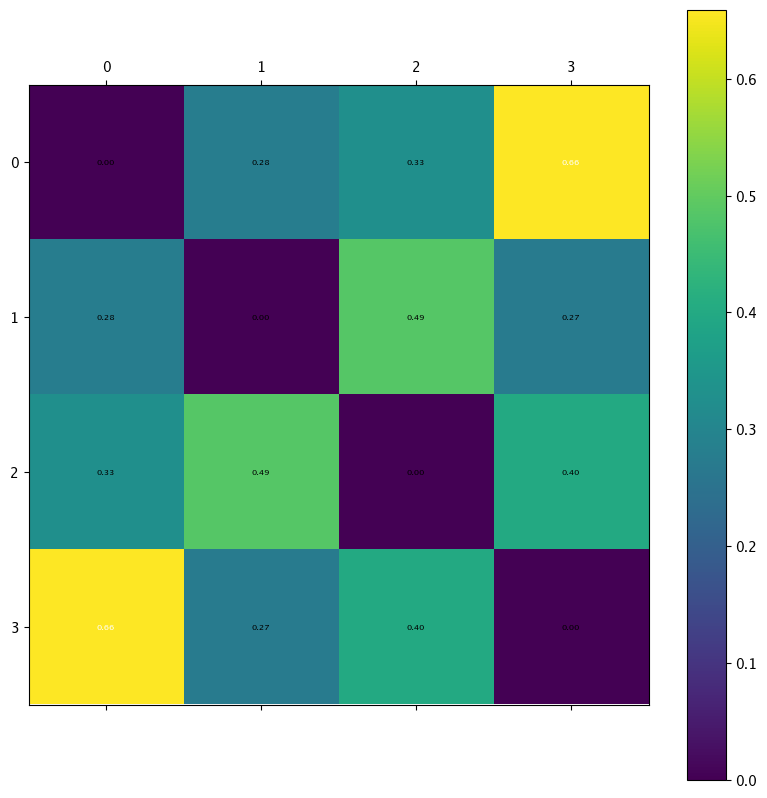

Attempting camera adjustment...
Fine-tuning failed: Camera parameters adjusting failed.
Using position-based cameras without adjustment
ESP esp_2: 1253x958
ESP esp_3: 1199x1001
ESP esp_4: 675x486
ESP esp_1: 1320x909
Applying wave correction...
Warping images to spherical projection...
Warped image count: 4
Corner positions: [(417, 146), (76, 90), (-233, 199), (-751, 106)]
Finding optimal seams...
Compensating exposure differences...
Blending images...
Position-based stitching successful: 1398x536


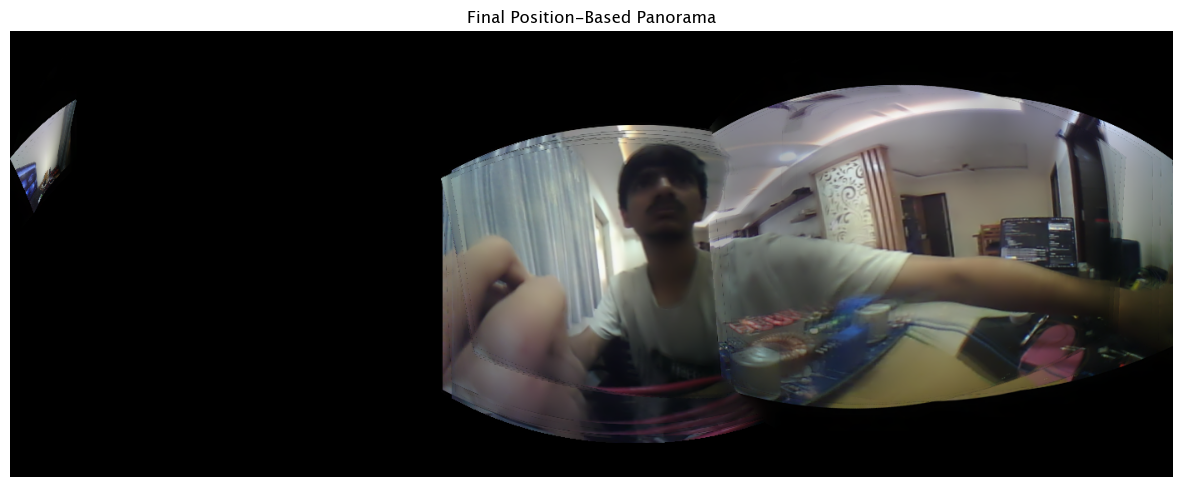


Final panorama saved: final_position_based_panorama.jpg
Final size: 1398x536


In [5]:
from cv2.detail import BundleAdjusterReproj
class Camera:
    """Simple camera representation for stitching library compatibility"""
    def __init__(self, focal=1000, ppx=0, ppy=0, aspect=1.0, R=None, t=None):
        self.focal = focal
        self.aspect = aspect
        self.ppx = ppx
        self.ppy = ppy
        if R is not None:
            self.R = R.copy()
        else:
            self.R = np.eye(3, dtype=np.float32)
        if t is not None:
            self.t = t.copy()
        else:
            self.t = np.zeros(3, dtype=np.float32)
            
    @property
    def K(self):
        return np.array([
            [self.focal, 0, self.ppx],
            [0, self.focal * self.aspect, self.ppy],
            [0, 0, 1]
        ], dtype=np.float32)

def create_position_based_cameras(panoramas, positions, base_focal=1000):
    """Create OpenCV-compatible cameras based on known ESP positions"""
    cameras = []
    esp_ids = []
    
    sorted_esps = sorted([(esp_id, pos) for esp_id, pos in positions.items() 
                         if esp_id in panoramas], key=lambda x: x[1])
    
    print("Creating position-based cameras:")
    for esp_id, angle_deg in sorted_esps:
        esp_ids.append(esp_id)
        
        # Rotation matrix (Y-axis rotation)
        angle_rad = np.radians(angle_deg)
        cos_a, sin_a = np.cos(-angle_rad), np.sin(-angle_rad)
        R = np.array([[cos_a, 0, sin_a],
                      [0, 1, 0],
                      [-sin_a, 0, cos_a]], dtype=np.float32)
        
        # Image size → principal point
        h, w = panoramas[esp_id].shape[:2]
        
        # Construct OpenCV CameraParams
        cam = cv.detail_CameraParams()
        cam.focal = base_focal
        cam.aspect = 1.0
        cam.ppx = w / 2.0
        cam.ppy = h / 2.0
        cam.R = R
        cam.t = np.zeros((3, 1), np.float32)  # no translation
        
        cameras.append(cam)
        
        direction = {0: "Front", 90: "Left", 180: "Back", 270: "Right"}.get(angle_deg, f"{angle_deg}°")
        print(f"  ESP {esp_id} ({direction}, {angle_deg}°): focal={cam.focal}")
    
    return cameras, esp_ids


def try_fine_tune_cameras(cameras: List[Camera], 
                         esp_ids: List[str],
                         panoramas: Dict[str, np.ndarray],
                         detector_type: str = "orb",
                         n_features: int = 5000) -> List[Camera]:
    """Try to fine-tune camera positions using feature matches"""
    print(f"\nAttempting fine-tuning with {n_features} features...")
    
    try:
        # Prepare images
        imgs = [resize_to_megapix(panoramas[esp_id], 1.2, allow_upscale=False) 
                for esp_id in esp_ids]
        
        # Detect features
        if detector_type == "orb":
            finder = FeatureDetector(detector=detector_type, nfeatures=n_features)
        else:
            finder = FeatureDetector(detector=detector_type)
        features = [finder.detect_features(img) for img in imgs]
        
        feature_counts = [len(f.keypoints) for f in features]
        print(f"Features detected: {feature_counts}")
        
        if min(feature_counts) < 100:
            print("Too few features for fine-tuning, using position-based cameras")
            return cameras
        
        # Match features
        matcher = FeatureMatcher(matcher_type="homography", range_width=-1)
        matches_dbg = matcher.match_features(features)
        conf_matrix = matcher.get_confidence_matrix(matches_dbg)
        print("conf_matrix after get_confidence_matrix:", conf_matrix)
        
        # Count good matches
        print(len([m.confidence for m in matches_dbg]))
        good_matches = [m for m in matches_dbg if m.confidence > 0.5]
        print(f"Good matches found: {len(good_matches)}")
        
        fig, ax = plt.subplots(figsize=(min(12, 2+2*conf_matrix.shape[0]), min(12, 2+2*conf_matrix.shape[1])))
        cax = ax.matshow(conf_matrix, interpolation='nearest')
        fig.colorbar(cax)
        for (i, j), z in np.ndenumerate(conf_matrix):
            ax.text(j, i, f"{z:0.2f}", ha='center', va='center', fontsize=6, color="white" if z > 0.5 else "black")
        plt.show()
        
        if len(good_matches) < 2:
            print("Too few matches for fine-tuning, using position-based cameras")
            return cameras
        
        # Try camera adjustment with low confidence threshold
        print("Attempting camera adjustment...")
        adjuster = CameraAdjuster(confidence_threshold=0.001)
        adjusted_cameras = adjuster.adjust(features, matches_dbg, cameras)
        
        print("Fine-tuning successful!")
        return adjusted_cameras
        
    except Exception as e:
        print(f"Fine-tuning failed: {e}")
        print("Using position-based cameras without adjustment")
        return cameras

def stitch_with_position_based_cameras(panoramas: Dict[str, np.ndarray], 
                                     positions: Dict[str, float],
                                     high_mpix: float = 1.2,
                                     try_fine_tune: bool = True) -> np.ndarray:
    """Stitch ESP panoramas using known positions with optional fine-tuning"""
    print(f"\n{'='*60}")
    print(f"STAGE 2: Position-based stitching of {len(panoramas)} ESP panoramas")
    print(f"{'='*60}")
    
    if len(panoramas) == 1:
        return list(panoramas.values())[0]
    
    # Create position-based cameras
    cameras, esp_ids = create_position_based_cameras(panoramas, positions, 250)
    
    if try_fine_tune:
        # Try to fine-tune cameras using feature matches
        # detectors - orb | brisk | akaze | sift
        cameras = try_fine_tune_cameras(cameras, esp_ids, panoramas, "orb", N_FEATURES_INTER)
    
    # Prepare images at high resolution
    imgs = []
    for esp_id in esp_ids:
        img = resize_to_megapix(panoramas[esp_id], high_mpix, allow_upscale=False)
        imgs.append(img)
        h, w = img.shape[:2]
        print(f"ESP {esp_id}: {w}x{h}")
    
    try:
        # Apply wave correction to smooth out any discontinuities
        print("Applying wave correction...")
        corrector = WaveCorrector()
        cameras = corrector.correct(cameras)
        
        # Warping using spherical projection
        print("Warping images to spherical projection...")
        warper = Warper("spherical")
        warper.set_scale(cameras)
        
        sizes = [(img.shape[1], img.shape[0]) for img in imgs]
        
        # Warp images and masks
        warped_imgs = list(warper.warp_images(imgs, cameras, aspect=1.0))
        warped_masks = list(warper.create_and_warp_masks(sizes, cameras, aspect=1.0))
        corners, sizes_out = warper.warp_rois(sizes, cameras, aspect=1.0)
        
        print(f"Warped image count: {len(warped_imgs)}")
        print(f"Corner positions: {corners}")
        
        # Seam finding
        print("Finding optimal seams...")
        seam_finder = SeamFinder()
        seam_masks = seam_finder.find(warped_imgs, corners, warped_masks)
        
        # Exposure compensation
        print("Compensating exposure differences...")
        compensator = ExposureErrorCompensator()
        compensator.feed(corners, warped_imgs, warped_masks)
        compensated_imgs = [
            compensator.apply(i, corner, img, mask)
            for i, (img, mask, corner) in enumerate(zip(warped_imgs, warped_masks, corners))
        ]
        
        # Blending
        print("Blending images...")
        blender = Blender()
        blender.prepare(corners, sizes_out)
        for img, mask, corner in zip(compensated_imgs, seam_masks, corners):
            blender.feed(img, mask, corner)
        
        result, _ = blender.blend()
        
        print(f"Position-based stitching successful: {result.shape[1]}x{result.shape[0]}")
        return result
        
    except Exception as e:
        print(f"Position-based spherical stitching failed: {e}")
        print("Falling back to simple sequential stitching...")
        
        # Fallback: sequential homography stitching in angular order
        result = imgs[0]
        for i in range(1, len(imgs)):
            print(f"Stitching ESP {esp_ids[0]} with ESP {esp_ids[i]}...")
            result = simple_stitch_pair(result, imgs[i], DETECTOR, N_FEATURES_INTER)
        
        return result

# Perform Stage 2 stitching using position information
print("Starting Stage 2: Position-based inter-ESP stitching...")
final_panorama = stitch_with_position_based_cameras(
    esp_panoramas, 
    ESP_POSITIONS, 
    HIGH_MPIX,
    try_fine_tune=True  # Set to False to skip fine-tuning
)

# Show final result
plot_image(final_panorama, figsize=(15, 10), title="Final Position-Based Panorama")

# Save final result
final_output_path = "final_position_based_panorama.jpg"
cv.imwrite(final_output_path, final_panorama)
print(f"\nFinal panorama saved: {final_output_path}")
print(f"Final size: {final_panorama.shape[1]}x{final_panorama.shape[0]}")

## Summary and Analysis

In [6]:
print(f"\n{'='*80}")
print("POSITION-BASED TWO-STAGE STITCHING SUMMARY")
print(f"{'='*80}")
print(f"Stage 1 (Intra-ESP homography stitching):")
for esp_id, panorama in esp_panoramas.items():
    h, w = panorama.shape[:2]
    position = ESP_POSITIONS.get(esp_id, "unknown")
    direction = {0: "Front", 90: "Left", 180: "Back", 270: "Right"}.get(position, f"{position}°")
    print(f"  ESP {esp_id} ({direction}): {len(esp_groups[esp_id])} images → {w}x{h} panorama")

print(f"\nStage 2 (Position-based inter-ESP stitching):")
print(f"  Used known camera positions: Front(0°), Left(90°), Right(270°), Back(180°)")
print(f"  {len(esp_panoramas)} ESP panoramas → {final_panorama.shape[1]}x{final_panorama.shape[0]} final panorama")

print(f"\nAdvantages of position-based approach:")
print("  • Robust even with minimal feature overlap between ESP groups")
print("  • Uses physical knowledge to initialize camera orientations")
print("  • Optional fine-tuning with available feature matches")
print("  • More predictable and stable results")
print("  • Handles 360° coverage systematically")
print("  • Reduces dependency on feature detection quality")

print(f"\nTechnical details:")
print("  • ESP cameras positioned at ~90° intervals around a central point")
print("  • Each ESP camera rotation matrix created from known angular position")
print("  • Optional feature-based fine-tuning for minor adjustments")
print("  • Spherical warping preserves the 360° nature of the capture")
print("  • Wave correction smooths any remaining discontinuities")


POSITION-BASED TWO-STAGE STITCHING SUMMARY
Stage 1 (Intra-ESP homography stitching):
  ESP esp_1 (Right): 12 images → 3662x2523 panorama
  ESP esp_2 (Front): 12 images → 4971x3799 panorama
  ESP esp_3 (Left): 7 images → 1588x1326 panorama
  ESP esp_4 (Back): 11 images → 675x486 panorama

Stage 2 (Position-based inter-ESP stitching):
  Used known camera positions: Front(0°), Left(90°), Right(270°), Back(180°)
  4 ESP panoramas → 1398x536 final panorama

Advantages of position-based approach:
  • Robust even with minimal feature overlap between ESP groups
  • Uses physical knowledge to initialize camera orientations
  • Optional fine-tuning with available feature matches
  • More predictable and stable results
  • Handles 360° coverage systematically
  • Reduces dependency on feature detection quality

Technical details:
  • ESP cameras positioned at ~90° intervals around a central point
  • Each ESP camera rotation matrix created from known angular position
  • Optional feature-based f

## Optional: Compare with different settings

In [ ]:
# You can experiment with different parameters:

# Try without fine-tuning (pure position-based)
print(f"\n{'='*60}")
print("EXPERIMENT: Pure position-based (no fine-tuning)")
print(f"{'='*60}")

final_panorama_pure = stitch_with_position_based_cameras(
    esp_panoramas, 
    ESP_POSITIONS, 
    HIGH_MPIX,
    try_fine_tune=False
)

plot_image(final_panorama_pure, figsize=(15, 10), title="Pure Position-Based Panorama (No Fine-tuning)")

# Save pure position-based result
pure_output_path = "final_pure_position_panorama.jpg"
cv.imwrite(pure_output_path, final_panorama_pure)
print(f"Pure position-based panorama saved: {pure_output_path}")

## Advanced: Custom position adjustment

In [ ]:
def create_custom_position_cameras(panoramas: Dict[str, np.ndarray], 
                                 custom_positions: Dict[str, Tuple[float, float, float]]) -> List[Camera]:
    """Create cameras with custom pan, tilt, roll adjustments"""
    cameras = []
    esp_ids = []
    
    print(f"Creating custom position cameras:")
    for esp_id, (pan, tilt, roll, focal) in custom_positions.items():
        if esp_id not in panoramas:
            continue
            
        esp_ids.append(esp_id)
        
        # Convert angles to radians
        pan_rad = np.radians(pan)
        tilt_rad = np.radians(tilt)  
        roll_rad = np.radians(roll)
        
        # Create rotation matrices
        # Pan (Y-axis rotation)
        R_pan = np.array([[np.cos(-pan_rad), 0, np.sin(-pan_rad)],
                          [0, 1, 0],
                          [-np.sin(-pan_rad), 0, np.cos(-pan_rad)]], dtype=np.float32)
        
        # Tilt (X-axis rotation)  
        R_tilt = np.array([[1, 0, 0],
                           [0, np.cos(-tilt_rad), -np.sin(-tilt_rad)],
                           [0, np.sin(-tilt_rad), np.cos(-tilt_rad)]], dtype=np.float32)
        
        # Roll (Z-axis rotation)
        R_roll = np.array([[np.cos(-roll_rad), -np.sin(-roll_rad), 0],
                           [np.sin(-roll_rad), np.cos(-roll_rad), 0],
                           [0, 0, 1]], dtype=np.float32)
        
        # Combined rotation: R = R_roll * R_tilt * R_pan
        R = R_roll @ R_tilt @ R_pan
        
        # Get image size for principal point
        h, w = panoramas[esp_id].shape[:2]
        
        # Construct OpenCV CameraParams
        cam = cv.detail_CameraParams()
        cam.focal = focal
        cam.aspect = 1.0
        cam.ppx = w / 2.0
        cam.ppy = h / 2.0
        cam.R = R
        cam.t = np.zeros((3, 1), np.float32)  # no translation
        
        cameras.append(cam)
        print(f"  ESP {esp_id}: pan={pan}°, tilt={tilt}°, roll={roll}°")
    
    return cameras, esp_ids

# Example: Fine adjustments to the base positions
# You can modify these values if the initial result needs tweaking
CUSTOM_POSITIONS = {
    'esp_2': (0, 0, 0, 250),      # Front: pan=0°, tilt=0°, roll=0°, focal = 250
    'esp_3': (80, 0, 0, 220),     # Left: pan=90°, tilt=0°, roll=0°, focal = 250
    'esp_4': (165, 0, 0, 220),     # Back: pan=180°, tilt=0°, roll=0°, focal = 250
    'esp_1': (270, 0, 0, 250)    # Right: pan=270°, tilt=0°, roll=0°, focal = 250
}

# Uncomment to try custom positions:
print(f"\n{'='*60}")
print("EXPERIMENT: Custom position adjustments")
print(f"{'='*60}")

# custom_cameras, custom_esp_ids = create_custom_position_cameras(esp_panoramas, CUSTOM_POSITIONS, 250)
# ... (rest of stitching pipeline would go here)

print(f"\nTo experiment with custom positions:")
print(f"1. Modify the CUSTOM_POSITIONS dictionary above")
print(f"2. Uncomment the custom position experiment section")
print(f"3. Adjust pan/tilt/roll values as needed:")
print(f"   - Pan: horizontal rotation (0°=front, 90°=left, 180°=back, 270°=right)")
print(f"   - Tilt: vertical rotation (positive=up, negative=down)")
print(f"   - Roll: camera rotation around viewing axis")

In [ ]:
from cv2.detail import BundleAdjusterReproj
class Camera:
    """Simple camera representation for stitching library compatibility"""
    def __init__(self, focal=1000, ppx=0, ppy=0, aspect=1.0, R=None, t=None):
        self.focal = focal
        self.aspect = aspect
        self.ppx = ppx
        self.ppy = ppy
        if R is not None:
            self.R = R.copy()
        else:
            self.R = np.eye(3, dtype=np.float32)
        if t is not None:
            self.t = t.copy()
        else:
            self.t = np.zeros(3, dtype=np.float32)
            
    @property
    def K(self):
        return np.array([
            [self.focal, 0, self.ppx],
            [0, self.focal * self.aspect, self.ppy],
            [0, 0, 1]
        ], dtype=np.float32)

def stitch_with_position_based_cameras(panoramas: Dict[str, np.ndarray],
                                     high_mpix: float = 1.2) -> np.ndarray:
    """Stitch ESP panoramas using known positions with optional fine-tuning"""
    print(f"\n{'='*60}")
    print(f"STAGE 2: Position-based stitching of {len(panoramas)} ESP panoramas")
    print(f"{'='*60}")
    
    if len(panoramas) == 1:
        return list(panoramas.values())[0]
    
    # Create custom-position-based cameras
    cameras, esp_ids = create_custom_position_cameras(esp_panoramas, CUSTOM_POSITIONS)
    
    # Prepare images at high resolution
    imgs = []
    for esp_id in esp_ids:
        img = resize_to_megapix(panoramas[esp_id], high_mpix, allow_upscale=False)
        imgs.append(img)
        h, w = img.shape[:2]
        print(f"ESP {esp_id}: {w}x{h}")
    
    try:
        # Apply wave correction to smooth out any discontinuities
        print("Applying wave correction...")
        corrector = WaveCorrector()
        cameras = corrector.correct(cameras)
        
        # Warping using spherical projection
        print("Warping images to spherical projection...")
        warper = Warper("spherical")
        warper.set_scale(cameras)
        
        sizes = [(img.shape[1], img.shape[0]) for img in imgs]
        
        # Warp images and masks
        warped_imgs = list(warper.warp_images(imgs, cameras, aspect=1.0))
        warped_masks = list(warper.create_and_warp_masks(sizes, cameras, aspect=1.0))
        corners, sizes_out = warper.warp_rois(sizes, cameras, aspect=1.0)
        
        print(f"Warped image count: {len(warped_imgs)}")
        print(f"Corner positions: {corners}")
        
        # Seam finding
        print("Finding optimal seams...")
        seam_finder = SeamFinder()
        seam_masks = seam_finder.find(warped_imgs, corners, warped_masks)
        
        # Exposure compensation
        print("Compensating exposure differences...")
        compensator = ExposureErrorCompensator()
        compensator.feed(corners, warped_imgs, warped_masks)
        compensated_imgs = [
            compensator.apply(i, corner, img, mask)
            for i, (img, mask, corner) in enumerate(zip(warped_imgs, warped_masks, corners))
        ]
        
        # Blending
        print("Blending images...")
        blender = Blender()
        blender.prepare(corners, sizes_out)
        for img, mask, corner in zip(compensated_imgs, seam_masks, corners):
            blender.feed(img, mask, corner)
        
        result, _ = blender.blend()
        
        print(f"Position-based stitching successful: {result.shape[1]}x{result.shape[0]}")
        return result
        
    except Exception as e:
        print(f"Position-based spherical stitching failed: {e}")
        print("Falling back to simple sequential stitching...")
        
        # Fallback: sequential homography stitching in angular order
        result = imgs[0]
        for i in range(1, len(imgs)):
            print(f"Stitching ESP {esp_ids[0]} with ESP {esp_ids[i]}...")
            result = simple_stitch_pair(result, imgs[i], DETECTOR, N_FEATURES_INTER)
        
        return result

# Perform Stage 2 stitching using position information
print("Starting Stage 2: Custom Position-based inter-ESP stitching...")
final_panorama = stitch_with_position_based_cameras(
    esp_panoramas,
    HIGH_MPIX
)

# Show final result
plot_image(final_panorama, figsize=(15, 10), title="Final Position-Based Panorama")

# Save final result
final_output_path = "final_custom_position_based_panorama.jpg"
cv.imwrite(final_output_path, final_panorama)
print(f"\nFinal panorama saved: {final_output_path}")
print(f"Final size: {final_panorama.shape[1]}x{final_panorama.shape[0]}")